In [3]:
import os
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from dotenv import load_dotenv
from scipy import stats
from statsmodels.stats.anova import AnovaRM

from multipred.plotting import (barplot_morey, plot_learning_interaction,
                                pointplot_morey)

In [4]:
load_dotenv("../../.env")
PROJECT_PATH = os.getenv("PROJECT_PATH")
DATA_PATH = f"{PROJECT_PATH}/data/derivatives/decoding_data"
ROI = "EVC"
N_VOXELS = "wholeROI"

# Loading balanced data

In [5]:
# Balanced data will be used for most of the analyses
balanced_df = pd.read_csv(f"{DATA_PATH}/{ROI}_{N_VOXELS}/balanced_group_data.csv") 
            
balanced_df["correct"] = balanced_df["correct"].astype(int)
balanced_df["pred"] = balanced_df["pred"].astype(str)
balanced_df["ign_pred"] = balanced_df["ign_pred"].astype(str)
balanced_df["v_pred"] = np.where(balanced_df["modality"] == "visual", balanced_df["pred"], balanced_df["ign_pred"])
balanced_df["a_pred"] = np.where(balanced_df["modality"] == "auditory", balanced_df["pred"], balanced_df["ign_pred"])
balanced_df["v_learned"] = balanced_df["v_learned"].astype(str)
balanced_df["a_learned"] = balanced_df["a_learned"].astype(str)
balanced_df["expected_stim"] = np.where(balanced_df["expected_stim"] == 0, "CW", "CCW")
balanced_df["stim"] = np.where(balanced_df["stim"] == 0, "CW", "CCW")

balanced_df["z_distance_abs"] = np.abs(balanced_df["z_distance"])

balanced_df["v_learned"] = balanced_df["v_learned"].astype("category")
balanced_df["expected_stim"] = balanced_df["expected_stim"].astype("category")


# Loading and aggregating data from all trials across permutations

In [6]:
# The dataframe with all trials will be used to fit regression models with trial by trial measures
# The reason for this is that before fitting we need to aggreggate the data of each trial across permutations
# This can't be done with the balanced data, as it requires to have different sets of trials at each permutation
alltrials_df = pd.read_csv(f"{DATA_PATH}/{ROI}_{N_VOXELS}/group_data.csv") 
            
alltrials_df["correct"] = alltrials_df["correct"].astype(int)
alltrials_df["pred"] = alltrials_df["pred"].astype(str)
alltrials_df["ign_pred"] = alltrials_df["ign_pred"].astype(str)
alltrials_df["v_pred"] = np.where(alltrials_df["modality"] == "visual", alltrials_df["pred"], alltrials_df["ign_pred"])
alltrials_df["a_pred"] = np.where(alltrials_df["modality"] == "auditory", alltrials_df["pred"], alltrials_df["ign_pred"])
alltrials_df["v_learned"] = alltrials_df["v_learned"].astype(str)
alltrials_df["a_learned"] = alltrials_df["a_learned"].astype(str)
alltrials_df["expected_stim"] = np.where(alltrials_df["expected_stim"] == 0, "CW", "CCW")
alltrials_df["stim"] = np.where(alltrials_df["stim"] == 0, "CW", "CCW")

# Aggregate across perms, while retaining important columns
alltrials_df = alltrials_df.groupby(['subj', 'run', 'trial']).agg(
    correct=('correct', 'mean'), 
    modality=('modality', 'first'),
    v_pred=('v_pred', 'first'),
    a_pred=('a_pred', 'first'),
    v_learned=('v_learned', 'first'),
    a_learned=('a_learned', 'first'),
    classified_stim=('classified_stim', 'mean'),
    stim = ('stim', 'first'),
    expected_stim=('expected_stim', 'first'),
    z_distance=('z_distance', 'mean'),
    decision_distances=('decision_distances', 'mean'),
    prob_0=('prob_0', 'mean'),
    prob_1=('prob_1', 'mean'),
).reset_index()

# Binarize the 'correct' column
alltrials_df['correct'] = alltrials_df['correct'].round()


# Defining factors for pymer4 
v_pred = {"v_pred" : ["0", "1"]}
a_pred = {"a_pred" : ["0", "1"]}
v_learned = {"v_learned" : ["0", "1"]}
a_learned = {"a_learned" : ["0", "1"]}
expected_stim = {"expected_stim" : ["CW", "CCW"]}


### Visual attended

### Triple interaction

C:\Users\marcs\Documents\multipred-fmri\multipred\plotting.py:445: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat['subject_mean'] = dat.groupby(id_col)[y].transform('mean')
C:\Users\marcs\Documents\multipred-fmri\multipred\plotting.py:446: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat['cousineau_normalized'] = dat[y] - dat['subject_mean']
C:\Users\marcs\Documents\multipred-fmri\multipred\plotting.py:448: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try u

                         Anova
                          F Value Num DF  Den DF Pr > F
-------------------------------------------------------
stim                      14.9742 1.0000 24.0000 0.0007
expected_stim              2.4931 1.0000 24.0000 0.1274
a_pred                     0.6781 1.0000 24.0000 0.4183
stim:expected_stim         0.8343 1.0000 24.0000 0.3701
stim:a_pred                2.5728 1.0000 24.0000 0.1218
expected_stim:a_pred       5.4276 1.0000 24.0000 0.0286
stim:expected_stim:a_pred  1.5707 1.0000 24.0000 0.2222



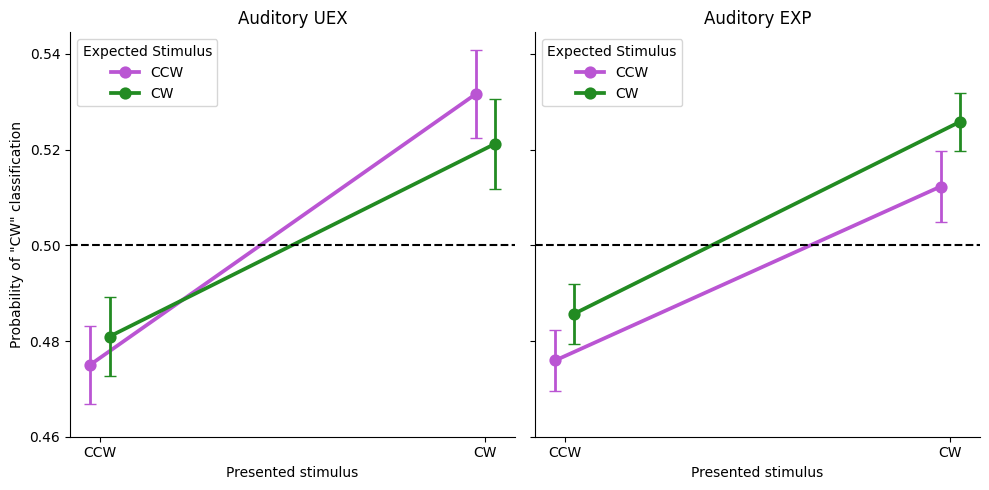

In [ ]:
x="stim" # Presented CW or
hue="expected_stim" # expected CW or CCW
col="a_pred" # auditory EXP or UEX
y="prob_1" # probability of choosing CW
id="subj" # subject id
savefig=False

data=balanced_df.copy()
dat = data[data["modality"] == "visual"].copy().groupby(
    [id, hue, x, col]
)[y].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
# plot x axis in order CCW, CW
# Loop through unique col levels
for i, col_level in enumerate(dat[col].unique()):
    pointplot_morey(dat[dat[col] == col_level], x, y, hue, id_col=id, swarmplot_plot=False, palette=["mediumorchid", "forestgreen"], dodge_width=0.05, hline = 0.5, ax=axes[i])
    exp_label="UEX" if col_level=="0" else "EXP"
    axes[i].set_title(f"Auditory {exp_label}")
    axes[i].legend().set_title("Expected Stimulus")
    axes[i].set_xlabel("Presented stimulus")
    axes[i].set_xticklabels(["CCW", "CW"])
    axes[i].set_ylabel(f'Probability of "CW" classification')
    axes[i].set_yticks(np.linspace(0.46, .54, 5))
    # Format y-axis as percentage rounded
    #axes[i].yaxis.set_major_formatter(mtick.PercentFormatter(1, decimals=0))

# Run the three-way repeated measures ANOVA
# Effect sizes (partial eta squared) reported in the manuscript were calculated in R
aov = AnovaRM(data=dat, 
              depvar=y, #"classified_stim",  # Dependent Variable
              subject=id,             # Subject ID (repeated measures)
              within=[x, hue, col])  # Within-subject factors

result = aov.fit()
print(result)

plt.tight_layout()
plt.show()

if savefig:
    fig.savefig(f"figures/MVPA/{ROI}_bias.svg", dpi=300)

/tmp/ipykernel_2654104/1505477909.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels([tick for tick in original_ticks]) # Set new labels formatted as percentages


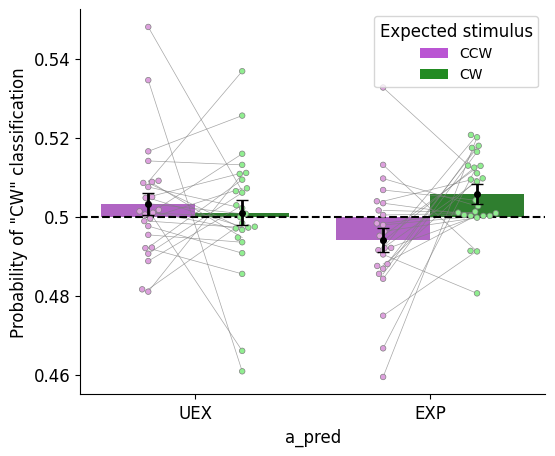

                      Anova
                     F Value Num DF  Den DF Pr > F
--------------------------------------------------
a_pred                0.6781 1.0000 24.0000 0.4183
expected_stim         2.4931 1.0000 24.0000 0.1274
a_pred:expected_stim  5.4276 1.0000 24.0000 0.0286

TtestResult(statistic=np.float64(-0.5038598289313646), pvalue=np.float64(0.6189538921909312), df=np.int64(24))
TtestResult(statistic=np.float64(2.9503153364232304), pvalue=np.float64(0.006981167561499174), df=np.int64(24))


In [49]:
x="a_pred" # auditory EXP or UEX
hue="expected_stim" # expected CW or CCW
y="centered_prob" # probability of choosing CW
id="subj" # subject id
data=balanced_df.copy()
data["centered_prob"] = data["prob_1"] - 0.5

# Direct comparisons between expected stimuli ( without taking into account the presented stimulus)
dat = data[(data["modality"] == "visual")].copy().groupby(
    [id, hue, x]
)[y].mean().reset_index()


palette1 = ["mediumorchid", "forestgreen"]
palette2 = ["plum", "lightgreen"]

fig, ax = plt.subplots(1, 1, figsize=(6, 5))

barplot_morey(dat, x, y, hue, "Expected stimulus", palette1, palette2, True, True, True, ax)
ax.set_xticks([0, 1], ["UEX", "EXP"])
ax.set_ylabel(f'Probability of "CW" classification') #plt.ylabel(f"probability of classifying CCW")

# Get the current y-tick values (which are in centered probability space)
y_ticks = plt.gca().get_yticks()
original_ticks = [tick + 0.5 for tick in y_ticks] # convert to original probability space
#plt.gca().set_yticklabels([f"{tick*100:.0f}%" for tick in original_ticks]) # Set new labels formatted as percentages
plt.gca().set_yticklabels([tick for tick in original_ticks]) # Set new labels formatted as percentages

plt.axhline(0, color='black', linestyle='--')
sns.despine()
plt.show()

# two-way repeated measures ANOVA
aov = AnovaRM(data=dat, 
              depvar=y, #"classified_stim",  # Dependent Variable
              subject=id,             # Subject ID (repeated measures)
              within=[x, hue])  # Within-subject factors

result = aov.fit()
print(result)

for a_pred in dat["a_pred"].unique():
    a = dat[(dat["a_pred"]==a_pred) & (dat["expected_stim"]=="CW")].groupby("subj")[y].mean()
    b = dat[(dat["a_pred"]==a_pred) & (dat["expected_stim"]=="CCW")].groupby("subj")[y].mean()
    print(stats.ttest_rel(a, b))

### LMMs to assess effect of trial by trial explicit knowledge 

(if prediction was explictly recalled in the final explicit test by the participant or not)

In [25]:
alltrials_df["expected_stim"] = alltrials_df["expected_stim"].astype("category")
alltrials_df["stim"] = alltrials_df["stim"].astype("category")
alltrials_df["v_learned"] = alltrials_df["v_learned"].astype("category")
alltrials_df["a_learned"] = alltrials_df["a_learned"].astype("category")
alltrials_df["a_pred"] = alltrials_df["a_pred"].astype("category")

In [26]:
dat = alltrials_df[(alltrials_df["modality"]=="visual") & (alltrials_df["a_pred"]=="1")].copy()
md = sm.MixedLM.from_formula("prob_1 ~ expected_stim * v_learned", data=dat, groups=dat["subj"])
mdf = md.fit()
print(mdf.summary())

                    Mixed Linear Model Regression Results
Model:                     MixedLM         Dependent Variable:         prob_1
No. Observations:          3312            Method:                     REML  
No. Groups:                23              Scale:                      0.0112
Min. group size:           144             Log-Likelihood:             inf   
Max. group size:           144             Converged:                  Yes   
Mean group size:           144.0                                             
-----------------------------------------------------------------------------
                                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------
Intercept                           0.000                                    
expected_stim[T.CW]                 0.024    0.006  4.426 0.000  0.014  0.035
v_learned[T.1]                     -0.030    0.008 -3.591 0.000 -0.046 -0.013
expect

/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWar

In [17]:
dat.groupby(["v_learned"])["v_pred"].value_counts()

v_learned  v_pred
0          1         1500
           0          300
1          1         1260
           0          252
Name: count, dtype: int64

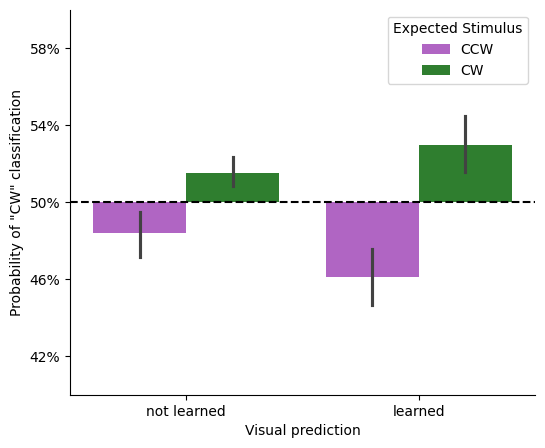

In [27]:
x = "v_learned"
hue = "expected_stim"

# Create a new column with the centered probability
dat["centered_prob"] = dat["prob_1"] - 0.5
y = "centered_prob"
dat = dat.groupby([hue, x, id])[y].mean().reset_index()
palette = ["mediumorchid", "forestgreen"]

# Create figure and axis
fig, ax = plt.subplots(figsize=(6, 5))

# Call function with ax
plot_learning_interaction(dat, x, y, hue, "CW", palette, 0, ax)

# Show the plot
plt.show()

### EXTRA analyses

In [20]:
dat = alltrials_df[(alltrials_df["modality"]=="visual")].copy() # & (alltrials_df["a_pred"]=="1")].copy()
md = sm.MixedLM.from_formula("prob_1 ~ stim * expected_stim * v_learned", data=dat, groups=dat["subj"])
mdf = md.fit()
print(mdf.summary())

                          Mixed Linear Model Regression Results
Model:                        MixedLM            Dependent Variable:            prob_1   
No. Observations:             4800               Method:                        REML     
No. Groups:                   25                 Scale:                         0.0082   
Min. group size:              192                Log-Likelihood:                4674.3825
Max. group size:              192                Converged:                     Yes      
Mean group size:              192.0                                                      
-----------------------------------------------------------------------------------------
                                              Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------------------
Intercept                                      0.485    0.003 164.066 0.000  0.479  0.491
stim[T.CW]                          

/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


/media/wiseman/tocho/multipred-fmri/multipred/plotting.py:445: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat['subject_mean'] = dat.groupby(id_col)[y].transform('mean')
/media/wiseman/tocho/multipred-fmri/multipred/plotting.py:446: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat['cousineau_normalized'] = dat[y] - dat['subject_mean']
/media/wiseman/tocho/multipred-fmri/multipred/plotting.py:448: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[ro

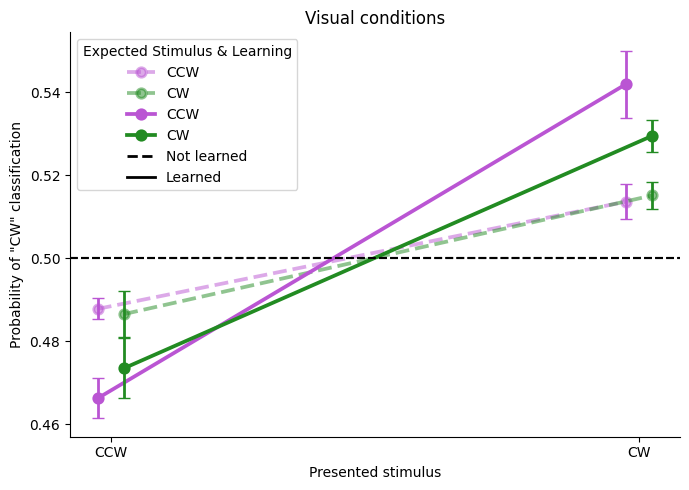

In [21]:
y = "prob_1"
x = "stim"
hue = "expected_stim"
id = "subj"
col = "v_learned"

fig, ax = plt.subplots(figsize=(7, 5))

# Define line styles
line_styles = {"0": "dashed", "1": "solid"}
line_alpha = {"0": 0.5, "1": 1}
exp_labels = {"0": "Not learned", "1": "Learned"}

# Iterate over the two levels of v_learned and plot them on the same axis
for col_level in ["0", "1"]:
    subset = dat[dat[col] == col_level]
    pointplot_morey(
        subset, x, y, hue, id_col=id,
        swarmplot_plot=False, 
        palette=["mediumorchid", "forestgreen"],
        dodge_width=0.05, 
        hline=0.5, 
        linestyle=line_styles[col_level],
        linealpha=line_alpha[col_level],
        ax=ax
    )
    

# Adjust labels and legend
ax.set_title("Visual conditions")
ax.legend(title="Expected Stimulus")
ax.set_xlabel("Presented stimulus")
ax.set_xticklabels(["CCW", "CW"])
ax.set_ylabel(f'Probability of "CW" classification')
ax.set_yticks(np.linspace(0.46, .54, 5))

# Add a manual legend for v_learned
handles, labels = ax.get_legend_handles_labels()
custom_lines = [
    plt.Line2D([0], [0], linestyle="dashed", color="black", lw=2, label="Not learned"),
    plt.Line2D([0], [0], linestyle="solid", color="black", lw=2, label="Learned")
]
ax.legend(handles=handles + custom_lines, title="Expected Stimulus & Learning")

plt.tight_layout()
plt.show()


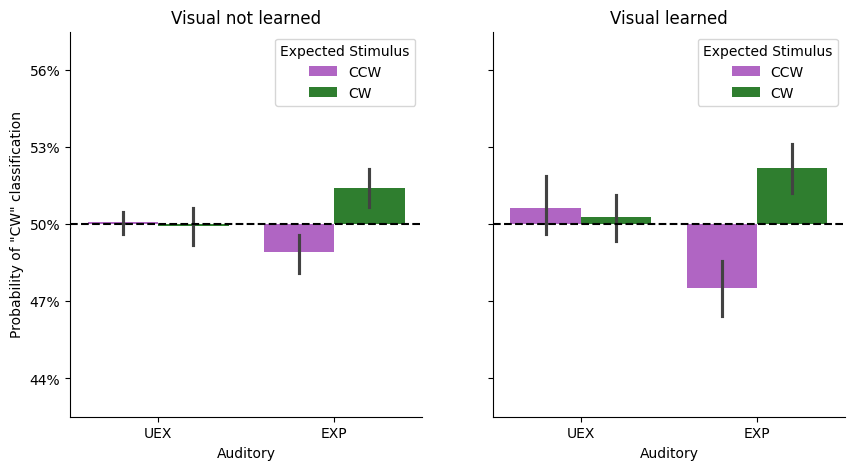

In [ ]:
y = "centered_prob"
x = "a_pred"
hue = "expected_stim"
id = "subj"
col = "v_learned"

# Create a new column with the centered probability
dat["centered_prob"] = dat["prob_1"] - 0.5
# Direct comparisons between expected stimuli ( without taking into account the presented stimulus)
dat = dat.groupby([id, hue, x, col])[y].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
for i, col_level in enumerate(np.sort(dat[col].unique())):
    plot_learning_interaction(dat[dat[col] == col_level], x, y, hue, "CW", palette, 0, axes[i])
    col_label = "not learned" if col_level == "0" else "learned"
    axes[i].set_title(f"Visual {col_label}")